# Aim 1 replication — baseline interferon and response shape in 1M-scBloodNL

**Finding to replicate (Parse 10M PBMC):** donors with normal baseline interferon respond to a stimulus with the same *shape* and differ mainly in *size*; donors with high baseline interferon differ in the *shape* of their responses.

**Independent data:** 1M-scBloodNL (Oelen et al. 2022). 120 donors, PBMCs untreated (UT) or stimulated with *C. albicans*, *M. tuberculosis* or *P. aeruginosa* for 3 h or 24 h; 10x v2 and v3 chemistries (analyzed separately).

**Test (model-free, as in section 11 of the main notebook):**
1. Baseline interferon score per donor from its untreated cells.
2. For every donor, stimulus and cell type: how far the donor's response is from the other donors' mean response, split exactly into a **size** part and a **shape** part, minus within-donor sampling noise.
3. **Main test:** does shape deviation increase with baseline interferon (Spearman, per stimulus x cell type), more than size deviation does? Controlled for the donor's cell count.
4. Pair-type table as in Parse, with high-IFN donors defined as the top quartile of the score.

**Differences from Parse:** only 6 stimulation conditions (no COMPASS decomposition), untreated cells are the reference (no inert-cytokine controls or replicate control wells), and each donor x condition is one well, so well noise cannot be corrected. Well noise should not depend on a donor's interferon score, so it lowers power but should not create the correlation.

In [1]:
import os, gzip, json
import numpy as np, pandas as pd, scipy.sparse as sp
import matplotlib.pyplot as plt, seaborn as sns
from scipy.stats import spearmanr

DATA_DIR    = "data/scbloodnl"
CACHE_DIR   = os.path.join(DATA_DIR, "cache")
RESULTS_DIR = "results/aim1_replication"
os.makedirs(CACHE_DIR, exist_ok=True); os.makedirs(RESULTS_DIR, exist_ok=True)

CHEMS          = ["V2", "V3"]
CELL_TYPES     = ["monocyte", "CD4T", "CD8T", "NK", "B"]   # 'cell_type_lowerres' labels
CONTROL        = "UT"
MIN_CELLS      = 10     # per donor x condition x cell type
MIN_CELLS_HALF = 5      # per random half
MIN_CPM        = 20     # gene must reach this mean CPM in untreated cells of the cell type
N_GENES        = 2000
CHUNK_LINES    = 20_000_000
SEED           = 0

# Core interferon-stimulated genes for the baseline score
ISG = ["IFI27", "IFI44L", "IFI44", "IFI6", "IFIT1", "IFIT2", "IFIT3", "ISG15", "MX1", "MX2",
       "OAS1", "OAS2", "OAS3", "RSAD2", "HERC5", "XAF1", "EPSTI1", "CMPK2", "STAT1", "IFITM3"]

## 1. Metadata

In [2]:
cells = pd.read_csv(f"{DATA_DIR}/1M_assignments_conditions_expid.tsv", sep="\t")
ctype = pd.read_csv(f"{DATA_DIR}/1M_cell_types.tsv", sep="\t")
cells = cells.merge(ctype[["barcode", "cell_type_lowerres"]], on="barcode", how="left")
cells = cells.dropna(subset=["assignment"])
cells["donor"] = cells["assignment"].astype(int).astype(str)
cells["condition"] = cells["timepoint"].astype(str)
print(cells.groupby(["chem", "condition"]).size().unstack(0))
print("\ncell types:", cells.cell_type_lowerres.value_counts().to_dict())

chem           V2     V3
condition               
24hCA       90632  51113
24hMTB      87053  38362
24hPA       88519  36256
3hCA        85917  57152
3hMTB       84625  40978
3hPA       111000  41546
UT          77931  37190

cell types: {'CD4T': 327724, 'CD8T': 214248, 'monocyte': 184205, 'NK': 130494, 'B': 20666, 'DC': 20277, 'unknown': 17486, 'megakaryocyte': 9597, 'hemapoietic stem': 2127, 'plasma B': 1450}


## 2. Pseudobulks (streamed from the .mtx.gz files, cached)
The matrix is read in chunks of lines, so it never has to fit in memory. Counts are summed per **donor x condition x cell type x random half**.

In [3]:
def read_lines_header(path):
    # returns (number of comment lines, (n_rows, n_cols, nnz))
    with gzip.open(path, "rt") as f:
        n = 0
        for line in f:
            if line.startswith("%"):
                n += 1; continue
            return n, tuple(int(x) for x in line.split())

def pseudobulk(chem):
    tag = chem.lower()
    f_cache = os.path.join(CACHE_DIR, f"pb_{tag}.npz")
    if os.path.exists(f_cache):
        z = np.load(f_cache, allow_pickle=True)
        print(f"{chem}: loaded cache")
        return z["sums"], pd.DataFrame(z["meta"].tolist(), columns=["donor", "cell_type", "condition", "half", "n_cells"]), z["genes"]

    mtx = f"{DATA_DIR}/10x_{tag}_RNA_matrix.mtx.gz"
    feats = pd.read_csv(f"{DATA_DIR}/10x_{tag}_RNA_features.tsv.gz", sep="\t", header=None)
    genes = feats.iloc[:, 1 if feats.shape[1] > 1 else 0].astype(str).to_numpy()
    bcs = pd.read_csv(f"{DATA_DIR}/10x_{tag}_barcodes.tsv.gz", sep="\t", header=None)[0].astype(str).to_numpy()

    n_comment, (n_rows, n_cols, nnz) = read_lines_header(mtx)
    genes_are_rows = (n_rows == len(genes))
    n_cells = n_cols if genes_are_rows else n_rows
    assert n_cells == len(bcs), f"barcodes ({len(bcs)}) do not match matrix ({n_rows} x {n_cols})"

    meta_c = cells.set_index("barcode").reindex(bcs)
    keep = meta_c.cell_type_lowerres.isin(CELL_TYPES).to_numpy() & meta_c.donor.notna().to_numpy()
    half = np.random.default_rng(SEED).integers(0, 2, len(bcs))
    key = pd.Series(list(zip(meta_c.donor, meta_c.cell_type_lowerres, meta_c.condition, half)))
    code_, uniq = pd.factorize(key.where(keep))
    code_ = np.where(keep, code_, -1)
    n_groups = len(uniq)
    G = sp.csr_matrix((np.ones(keep.sum(), np.float32), (code_[keep], np.where(keep)[0])),
                      shape=(n_groups, n_cells))
    sums = np.zeros((n_groups, len(genes)), np.float32)

    reader = pd.read_csv(mtx, sep=" ", header=None, skiprows=n_comment + 1, chunksize=CHUNK_LINES,
                         dtype={0: np.int64, 1: np.int64, 2: np.float32})
    done = 0
    for ch in reader:
        r, c, v = ch[0].to_numpy() - 1, ch[1].to_numpy() - 1, ch[2].to_numpy()
        cell_i, gene_i = (c, r) if genes_are_rows else (r, c)
        X = sp.csr_matrix((v, (cell_i, gene_i)), shape=(n_cells, len(genes)))
        sums += (G @ X).toarray()
        done += len(ch); print(f"\r{chem}: {done:,}/{nnz:,} entries", end="")
    meta = pd.DataFrame(list(uniq), columns=["donor", "cell_type", "condition", "half"])
    meta["n_cells"] = np.bincount(code_[keep], minlength=n_groups)
    np.savez(f_cache, sums=sums, meta=meta.to_numpy(dtype=object), genes=genes)
    print(f"\n{chem}: cached")
    return sums, meta, genes

PB = {chem: pseudobulk(chem) for chem in CHEMS}

V2: loaded cache
V3: loaded cache


## 3. Baseline interferon score
Per donor: mean z-scored log CPM of core ISGs in **untreated** cells, averaged over cell types (z-scores computed across donors within each chemistry and cell type).

/tmp/ipykernel_3146965/1368113071.py:21: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  per_ct[ct] = ((M - M.mean()) / (M.std() + 1e-9)).mean(1)
/tmp/ipykernel_3146965/1368113071.py:21: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  per_ct[ct] = ((M - M.mean()) / (M.std() + 1e-9)).mean(1)
/tmp/ipykernel_3146965/1368113071.py:21: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  per_ct[ct] = ((M - M.mean()) / (M.std() + 1e-9)).mean(1)
/tmp/ipykernel_3146965/1368113071.py:21: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  per_ct[ct] = ((M - M.mean()) / (M.std() + 1e-9)).mean(1)
/tmp/ipykernel_3146965/1368113071.py:21: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  per_ct[ct] = ((M - M.mean()) / (M.std() + 1e-9)).mean(1)
/tmp/ipykernel_3146965/1368113071.p

V2: 72 donors, ISGs found: 20/20
V3: 32 donors, ISGs found: 20/20


/tmp/ipykernel_3146965/1368113071.py:21: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  per_ct[ct] = ((M - M.mean()) / (M.std() + 1e-9)).mean(1)
/tmp/ipykernel_3146965/1368113071.py:22: Pandas4Warning: Starting with pandas version 4.0 all arguments of mean will be keyword-only.
  IFN_SCORE[chem] = pd.DataFrame(per_ct).mean(1).rename("ifn_score")


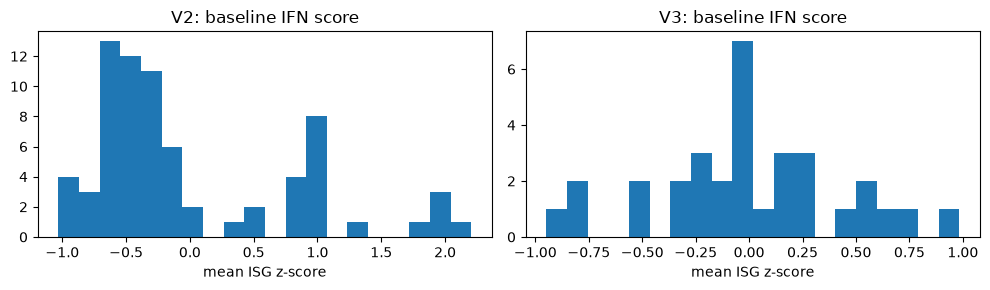

In [4]:
def logcpm(x):
    return np.log1p(x / max(x.sum(), 1) * 1e6)

def profile(sums, meta, donor, ct, cond, half=None):
    m = (meta.donor == donor) & (meta.cell_type == ct) & (meta.condition == cond)
    if half is not None: m &= (meta.half == half)
    rows = meta[m]
    return sums[rows.index.to_numpy()].sum(0), int(rows.n_cells.sum())

IFN_SCORE = {}
for chem, (sums, meta, genes) in PB.items():
    gi = [i for i, g in enumerate(genes) if g in set(ISG)]
    per_ct = {}
    for ct in CELL_TYPES:
        vals = {}
        for d in meta.donor.unique():
            s, n = profile(sums, meta, d, ct, CONTROL)
            if n >= MIN_CELLS: vals[d] = logcpm(s)[gi]
        if len(vals) < 5: continue
        M = pd.DataFrame(vals).T
        per_ct[ct] = ((M - M.mean()) / (M.std() + 1e-9)).mean(1)
    IFN_SCORE[chem] = pd.DataFrame(per_ct).mean(1).rename("ifn_score")
    print(f"{chem}: {len(IFN_SCORE[chem])} donors, ISGs found: {len(gi)}/{len(ISG)}")

pd.concat({c: s for c, s in IFN_SCORE.items()}, names=["chem", "donor"]).to_csv(f"{RESULTS_DIR}/baseline_ifn_score.csv")
fig, ax = plt.subplots(1, len(IFN_SCORE), figsize=(5 * len(IFN_SCORE), 3))
for a, (chem, s) in zip(np.atleast_1d(ax), IFN_SCORE.items()):
    a.hist(s, bins=20); a.set_title(f"{chem}: baseline IFN score"); a.set_xlabel("mean ISG z-score")
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/baseline_ifn_score.png", dpi=150); plt.show()

### Processing-date check
High-IFN donors in v2 cluster on a few processing dates, so the score is partly technical. Later sections compare donors within dates.

count  mean   min   max
chem date                           
V2   180920      2 -0.73 -0.90 -0.55
     180921      5 -0.62 -1.03 -0.01
     180925      1 -0.67 -0.67 -0.67
     180927      3 -0.53 -0.75 -0.21
     180928      5 -0.32 -0.68  0.49
     181003      4  1.51  0.54  2.21
     181010      1  1.06  1.06  1.06
     181011      3  1.22  0.83  1.91
     181017      5  0.08 -0.45  0.89
     181018      2  0.38 -0.29  1.05
     181022      1 -0.36 -0.36 -0.36
     181029      5 -0.38 -0.69 -0.03
     181030      3 -0.29 -0.50 -0.06
     181107      3 -0.29 -0.74  0.38
     181114      4 -0.59 -0.87 -0.36
     181115      1 -0.86 -0.86 -0.86
     181121      5 -0.48 -0.68 -0.06
     181122      3 -0.58 -0.64 -0.48
     181213      8 -0.27 -0.35 -0.12
     181218      7  1.09  0.90  1.74
     181219      1  1.91  1.91  1.91
V3   190109      8  0.13 -0.25  0.56
     190114      7  0.41 -0.02  0.98
     190115      1  0.11  0.11  0.11
     190124      3 -0.07 -0.95  0.46
     190129      3 -0.53 -0.78 -0.33
     190130      2 -0.06 -0.11 -0.01
     190201      3 -0.31 -0.83 -0.05
     190204      5 -0.26 -0.47 -0.07

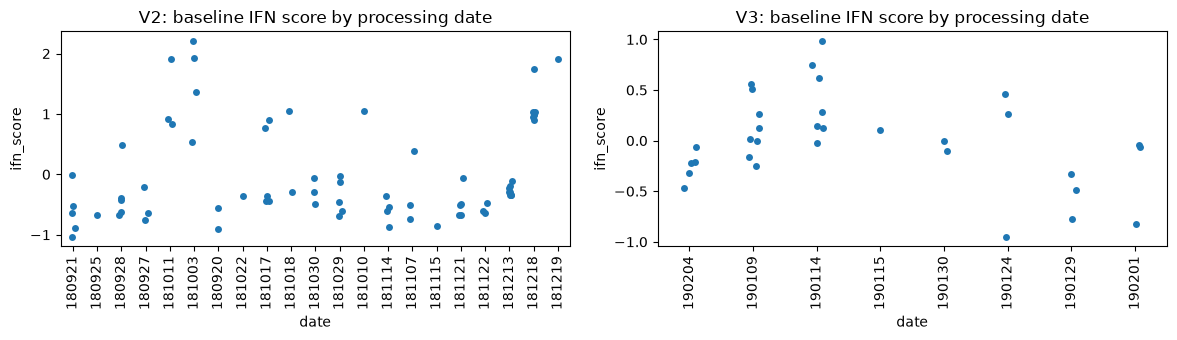

In [5]:
# Batch check: are high-IFN donors concentrated in a few processing dates?
cells["date"] = cells["barcode"].str.split("_").str[1]
donor_date = (cells.groupby(["chem", "donor"])["date"]
              .agg(lambda s: s.mode().iloc[0]).rename("date").reset_index())
score = pd.concat({c: s for c, s in IFN_SCORE.items()}, names=["chem", "donor"]).reset_index()
chk = score.merge(donor_date, on=["chem", "donor"])
chk.to_csv(f"{RESULTS_DIR}/ifn_score_by_date.csv", index=False)
display(chk.groupby(["chem", "date"]).ifn_score.agg(["count", "mean", "min", "max"]).round(2))
fig, ax = plt.subplots(1, len(CHEMS), figsize=(12, 3.5))
for a, chem in zip(np.atleast_1d(ax), CHEMS):
    sns.stripplot(data=chk[chk.chem == chem], x="date", y="ifn_score", ax=a)
    a.set_title(f"{chem}: baseline IFN score by processing date"); a.tick_params(axis="x", rotation=90)
plt.tight_layout(); fig.savefig(f"{RESULTS_DIR}/ifn_score_by_date.png", dpi=150); plt.show()

## 4. Responses and size/shape deviation (symmetric half-vs-half)
For donor $d$, stimulus $s$, cell type $c$, the response is log CPM(stimulated) - log CPM(untreated), per random half of cells. Donors are compared half A vs half B (between) and against their own halves (within), so sampling noise enters both sides the same way; the size/shape split is $(|a|-|b|)^2 + 2|a||b|(1-\cos)$. Deviations are computed against all other donors and against same-date donors only.
Note: simulations (step 2b) showed that this estimator is still biased when donors have unequal cell counts; section 7 gives the corrected version.

In [6]:
# Section 4 (revised): symmetric half-vs-half comparisons, as in the Parse analysis.
#   between(d, e) = half A of donor d vs half B of donor e
#   within(d)     = half A of donor d vs half B of donor d
# Both sides are half-samples, so sampling noise enters "between" and "within" the same way and cancels
# in the excess. A donor's deviation = mean excess over the donors it is compared with:
#   *_all  : against all other donors
#   *_date : only against donors processed on the same date (removes the processing-date effect)
def mag_shape(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    cos = a @ b / (na * nb + 1e-12)
    return (na - nb) ** 2, 2 * na * nb * (1 - cos)

date_map = {(c, d): dt for c, d, dt in donor_date[["chem", "donor", "date"]].itertuples(index=False)}

DEV = []
for chem, (sums, meta, genes) in PB.items():
    donors = sorted(IFN_SCORE[chem].index)
    stims = [s for s in meta.condition.unique() if s != CONTROL]
    for ct in CELL_TYPES:
        ut = [logcpm(profile(sums, meta, d, ct, CONTROL)[0]) for d in donors]
        expressed = np.expm1(np.mean(ut, 0)) >= MIN_CPM
        for stim in stims:
            R = {}
            for d in donors:
                sA, nA = profile(sums, meta, d, ct, stim, 0); sB, nB = profile(sums, meta, d, ct, stim, 1)
                uA, mA = profile(sums, meta, d, ct, CONTROL, 0); uB, mB = profile(sums, meta, d, ct, CONTROL, 1)
                if min(nA, nB, mA, mB) < MIN_CELLS_HALF or nA + nB < MIN_CELLS: continue
                R[d] = {"A": logcpm(sA) - logcpm(uA), "B": logcpm(sB) - logcpm(uB), "n": nA + nB}
            if len(R) < 10: continue
            F = np.array([(R[d]["A"] + R[d]["B"]) / 2 for d in R])
            var = np.where(expressed, F.var(0), -np.inf)
            gidx = np.argsort(var)[::-1][:min(N_GENES, expressed.sum())]
            A = {d: R[d]["A"][gidx] for d in R}; B = {d: R[d]["B"][gidx] for d in R}
            energy = np.mean([(A[d] @ A[d] + B[d] @ B[d]) / 2 for d in R])
            W = {d: mag_shape(A[d], B[d]) for d in R}
            for d in R:
                ex = {"all": [], "date": []}
                for e in R:
                    if e == d: continue
                    Mb, Sb = mag_shape(A[d], B[e])
                    Mw, Sw = (W[d][0] + W[e][0]) / 2, (W[d][1] + W[e][1]) / 2
                    ex["all"].append((Mb - Mw, Sb - Sw))
                    if date_map.get((chem, d)) == date_map.get((chem, e)):
                        ex["date"].append((Mb - Mw, Sb - Sw))
                row = dict(chem=chem, cell_type=ct, stimulus=stim, donor=d, n_cells=R[d]["n"],
                           date=date_map.get((chem, d)), ifn_score=IFN_SCORE[chem][d],
                           size_dev=np.mean([x[0] for x in ex["all"]]) / energy,
                           shape_dev=np.mean([x[1] for x in ex["all"]]) / energy,
                           n_same_date=len(ex["date"]))
                if ex["date"]:
                    row["size_dev_date"] = np.mean([x[0] for x in ex["date"]]) / energy
                    row["shape_dev_date"] = np.mean([x[1] for x in ex["date"]]) / energy
                DEV.append(row)
DEV = pd.DataFrame(DEV)
DEV.to_csv(f"{RESULTS_DIR}/size_shape_deviation_per_donor.csv", index=False)
print(DEV.groupby(["chem", "cell_type"]).size().unstack(0))

chem        V2   V3
cell_type          
B          258  114
CD4T       422  160
CD8T       422  160
NK         420  159
monocyte   417  160


## 5. Main test: does shape deviation track baseline interferon?
Spearman correlation of each donor's deviation with its baseline IFN score, per chemistry x stimulus x cell type. A partial correlation controlling for the donor's cell count guards against a quality confound (donors with fewer cells are noisier).

**Replication means:** `rho_shape` mostly positive and larger than `rho_size`.

rho_shape  rho_size  rho_shape_partial_ncells  \
chem cell_type                                                  
V2   B              0.101    -0.143                     0.110   
     CD4T           0.282     0.170                     0.264   
     CD8T           0.046     0.201                     0.062   
     NK            -0.016     0.019                     0.023   
     monocyte       0.051     0.346                     0.039   
V3   B              0.016    -0.122                    -0.014   
     CD4T          -0.009     0.205                    -0.062   
     CD8T           0.196     0.084                     0.153   
     NK            -0.141    -0.085                    -0.140   
     monocyte      -0.058     0.095                    -0.070   

                frac_stimuli_rho_shape_pos  
chem cell_type                              
V2   B                                1.00  
     CD4T                             0.83  
     CD8T                             0.67  
     NK                               0.33  
     monocyte                         0.50  
V3   B                                0.50  
     CD4T                             0.50  
     CD8T                             0.67  
     NK                               0.33  
     monocyte                         0.33

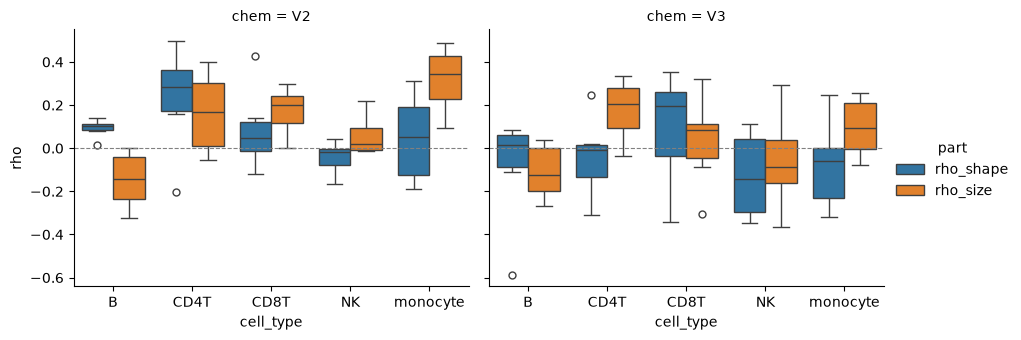

In [7]:
def partial_spearman(x, y, z):
    # rank-based partial correlation of x and y controlling for z
    import warnings
    rx, ry, rz = (pd.Series(v).rank().to_numpy() for v in (x, y, z))
    if np.ptp(rz) == 0: return spearmanr(rx, ry)[0]         # no variation in cell count
    def res(a, b):
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            return a - np.polyval(np.polyfit(b, a, 1), b)
    return spearmanr(res(rx, rz), res(ry, rz))[0]

TEST = []
for (chem, ct, stim), g in DEV.groupby(["chem", "cell_type", "stimulus"]):
    if len(g) < 10: continue
    TEST.append(dict(chem=chem, cell_type=ct, stimulus=stim, n_donors=len(g),
                     rho_shape=spearmanr(g.ifn_score, g.shape_dev)[0],
                     p_shape=spearmanr(g.ifn_score, g.shape_dev)[1],
                     rho_size=spearmanr(g.ifn_score, g.size_dev)[0],
                     rho_shape_partial_ncells=partial_spearman(g.ifn_score, g.shape_dev, np.log(g.n_cells))))
TEST = pd.DataFrame(TEST).round(3)
TEST.to_csv(f"{RESULTS_DIR}/ifn_vs_deviation_tests.csv", index=False)

SUMMARY = TEST.groupby(["chem", "cell_type"])[["rho_shape", "rho_size", "rho_shape_partial_ncells"]].median().round(3)
SUMMARY["frac_stimuli_rho_shape_pos"] = TEST.groupby(["chem", "cell_type"]).rho_shape.apply(lambda x: (x > 0).mean()).round(2)
SUMMARY.to_csv(f"{RESULTS_DIR}/ifn_vs_deviation_summary.csv")
display(SUMMARY)

g = sns.catplot(data=TEST.melt(id_vars=["chem", "cell_type", "stimulus"], value_vars=["rho_shape", "rho_size"],
                               var_name="part", value_name="rho"),
                x="cell_type", y="rho", hue="part", col="chem", kind="box", height=3.5, aspect=1.3)
for ax in g.axes.flat: ax.axhline(0, color="grey", ls="--", lw=0.8)
g.savefig(f"{RESULTS_DIR}/ifn_vs_deviation.png", dpi=150, bbox_inches="tight"); plt.show()

## 6. Pair-type view (as in Parse)
High-IFN donors = top quartile of the baseline score within each chemistry. Mean shape and size deviation by group.

In [8]:
DEV["ifn_group"] = DEV.groupby("chem").ifn_score.transform(lambda s: np.where(s >= s.quantile(0.75), "IFN-high", "other"))
GROUPS = DEV.groupby(["chem", "cell_type", "ifn_group"])[["size_dev", "shape_dev"]].mean().round(3)
GROUPS["share_size"] = (GROUPS.size_dev.clip(lower=0) /
                        (GROUPS.size_dev.clip(lower=0) + GROUPS.shape_dev.clip(lower=0))).round(2)
GROUPS.to_csv(f"{RESULTS_DIR}/ifn_group_deviation.csv")
GROUPS

size_dev  shape_dev  share_size
chem cell_type ifn_group                                 
V2   B         IFN-high      0.052      0.082        0.39
               other         0.085      0.045        0.65
     CD4T      IFN-high      0.130      0.467        0.22
               other         0.107      0.374        0.22
     CD8T      IFN-high      0.213      0.227        0.48
               other         0.159      0.189        0.46
     NK        IFN-high      0.202      0.057        0.78
               other         0.229      0.069        0.77
     monocyte  IFN-high      0.174      0.312        0.36
               other         0.092      0.266        0.26
V3   B         IFN-high      0.080      0.029        0.73
               other         0.119      0.029        0.80
     CD4T      IFN-high      0.043      0.398        0.10
               other         0.038      0.372        0.09
     CD8T      IFN-high      0.079      0.325        0.20
               other         0.076      0.315        0.19
     NK        IFN-high      0.103      0.154        0.40
               other         0.154      0.105        0.59
     monocyte  IFN-high      0.010      0.238        0.04
               other         0.007      0.226        0.03

### Within-date test
Deviation measured only against same-date donors, IFN score centered within date.

In [9]:
# Date-adjusted test (revised): deviation measured only against same-date donors, and the IFN score
# centered within each date. Neither side can then carry a processing-date effect.
def centered_rank(g, col):
    r = g[col].rank()
    return r - r.groupby(g["date"]).transform("mean")

ADJ = []
for (chem, ct, stim), g in DEV.dropna(subset=["shape_dev_date"]).groupby(["chem", "cell_type", "stimulus"]):
    g = g[g.groupby("date").donor.transform("count") >= 2]
    if len(g) < 10 or g.date.nunique() < 3: continue
    x = centered_rank(g, "ifn_score")
    ADJ.append(dict(chem=chem, cell_type=ct, stimulus=stim, n_donors=len(g), n_dates=g.date.nunique(),
                    rho_shape_within_date=spearmanr(x, g["shape_dev_date"])[0],
                    rho_size_within_date=spearmanr(x, g["size_dev_date"])[0]))
ADJ = pd.DataFrame(ADJ).round(3)
if ADJ.empty: raise SystemExit("No stimulus x cell type had enough donors on shared dates")
ADJ.to_csv(f"{RESULTS_DIR}/ifn_vs_deviation_within_date.csv", index=False)
ADJ_SUMMARY = ADJ.groupby(["chem", "cell_type"])[["rho_shape_within_date", "rho_size_within_date"]].median().round(3)
ADJ_SUMMARY["frac_stimuli_shape_pos"] = ADJ.groupby(["chem", "cell_type"]).rho_shape_within_date.apply(lambda s: (s > 0).mean()).round(2)
ADJ_SUMMARY["n_donors"] = ADJ.groupby(["chem", "cell_type"]).n_donors.median()
ADJ_SUMMARY.to_csv(f"{RESULTS_DIR}/ifn_vs_deviation_within_date_summary.csv")
ADJ_SUMMARY

rho_shape_within_date  rho_size_within_date  \
chem cell_type                                                
V2   B                          0.149                -0.071   
     CD4T                      -0.005                 0.024   
     CD8T                       0.014                 0.059   
     NK                        -0.038                -0.058   
     monocyte                  -0.005                -0.022   
V3   B                         -0.278                 0.010   
     CD4T                       0.038                 0.053   
     CD8T                      -0.090                 0.167   
     NK                        -0.007                 0.019   
     monocyte                   0.012                 0.109   

                frac_stimuli_shape_pos  n_donors  
chem cell_type                                    
V2   B                            0.83      38.0  
     CD4T                         0.50      66.5  
     CD8T                         0.67      66.5  
     NK                           0.17      66.0  
     monocyte                     0.50      65.5  
V3   B                            0.00      16.0  
     CD4T                         1.00      23.0  
     CD8T                         0.17      23.0  
     NK                           0.50      23.0  
     monocyte                     0.50      23.0

## 7. Corrected pipeline (validated by simulation)
The simulations (aim1_simulation.ipynb) showed that unequal cell counts bias every estimator, including the symmetric one used above, and that the combination below keeps false positives near 5% while detecting a real effect:
- **equal cell counts**: pseudobulk halves thinned to a common number of cells (binomial thinning of summed counts)
- **cross-half estimator**: norms and inner products only from independent halves
- **within-date comparison**

**Replication would mean** `rho_shape_within_date` positive in most cell types and larger than `rho_size_within_date`.

In [10]:
# ===== 7. Corrected pipeline (validated by simulation) =====
# Changes vs section 4:
#  (a) equal cell counts: every donor's pseudobulk halves (stimulated and untreated) are thinned to the
#      same number of cells (binomial thinning of the summed counts; approximates downsampling cells,
#      captures the counting noise but not cell-to-cell variation)
#  (b) cross-half estimator: norms and inner products built only from independent halves, so independent
#      sampling noise cancels in expectation
#  (c) same-date comparison, as before, to remove processing-date effects
# No well-noise correction is possible here (one well per donor x condition, no replicate control wells).
date_map = {(c_, d_): dt for c_, d_, dt in donor_date[["chem", "donor", "date"]].itertuples(index=False)}
MIN_EQUAL_HALF = 20        # donors with fewer cells than this in any half are dropped for that stimulus x cell type
rng_thin = np.random.default_rng(SEED)

def thin(counts, n_from, n_to):
    if n_from <= n_to: return counts.astype(np.float64)
    return rng_thin.binomial(np.round(counts).astype(np.int64), n_to / n_from).astype(np.float64)

def cross_parts(Ad, Bd, Ae, Be):
    nd2 = max(Ad @ Bd, 1e-12); ne2 = max(Ae @ Be, 1e-12)
    de = (Ad @ Be + Bd @ Ae) / 2
    nd, ne = np.sqrt(nd2), np.sqrt(ne2)
    cos = np.clip(de / (nd * ne), -1, 1)
    return (nd - ne) ** 2, 2 * nd * ne * (1 - cos)

DEV_C = []
for chem, (sums, meta, genes) in PB.items():
    donors = sorted(IFN_SCORE[chem].index)
    stims = [s for s in meta.condition.unique() if s != CONTROL]
    for ct in CELL_TYPES:
        ut = [logcpm(profile(sums, meta, d, ct, CONTROL)[0]) for d in donors]
        expressed = np.expm1(np.mean(ut, 0)) >= MIN_CPM
        for stim in stims:
            raw = {}
            for d in donors:
                parts = {k: profile(sums, meta, d, ct, cond, h)
                         for k, cond, h in [("sA", stim, 0), ("sB", stim, 1), ("uA", CONTROL, 0), ("uB", CONTROL, 1)]}
                if min(n for _, n in parts.values()) >= MIN_EQUAL_HALF:
                    raw[d] = parts
            if len(raw) < 10: continue
            target = min(n for p in raw.values() for _, n in p.values())      # common cells per half
            R = {}
            for d, p in raw.items():
                t = {k: thin(s, n, target) for k, (s, n) in p.items()}
                R[d] = {"A": logcpm(t["sA"]) - logcpm(t["uA"]), "B": logcpm(t["sB"]) - logcpm(t["uB"])}
            F = np.array([(R[d]["A"] + R[d]["B"]) / 2 for d in R])
            var = np.where(expressed, F.var(0), -np.inf)
            gidx = np.argsort(var)[::-1][:min(N_GENES, expressed.sum())]
            A = {d: R[d]["A"][gidx] for d in R}; B = {d: R[d]["B"][gidx] for d in R}
            energy = np.mean([A[d] @ B[d] for d in R])
            for d in R:
                ex = {"all": [], "date": []}
                for e in R:
                    if e == d: continue
                    m, s = cross_parts(A[d], B[d], A[e], B[e])
                    ex["all"].append((m, s))
                    if date_map.get((chem, d)) == date_map.get((chem, e)): ex["date"].append((m, s))
                row = dict(chem=chem, cell_type=ct, stimulus=stim, donor=d, cells_per_half=target,
                           date=date_map.get((chem, d)), ifn_score=IFN_SCORE[chem][d],
                           size_dev=np.mean([x[0] for x in ex["all"]]) / energy,
                           shape_dev=np.mean([x[1] for x in ex["all"]]) / energy)
                if ex["date"]:
                    row["size_dev_date"] = np.mean([x[0] for x in ex["date"]]) / energy
                    row["shape_dev_date"] = np.mean([x[1] for x in ex["date"]]) / energy
                DEV_C.append(row)
DEV_C = pd.DataFrame(DEV_C)
if DEV_C.empty: raise SystemExit(f"No stimulus x cell type had 10 donors with >= {MIN_EQUAL_HALF} cells per half; lower MIN_EQUAL_HALF")
DEV_C.to_csv(f"{RESULTS_DIR}/corrected_deviation_per_donor.csv", index=False)
print(DEV_C.groupby(["chem", "cell_type"]).agg(donors=("donor", "nunique"), cells_per_half=("cells_per_half", "median")))

                donors  cells_per_half
chem cell_type                        
V2   CD4T           72            49.0
     CD8T           72            32.0
     NK             69            22.0
     monocyte       69            21.0
V3   CD4T           32            42.0
     CD8T           32            26.0
     NK             31            23.0
     monocyte       32            47.0


In [11]:
# Tests with the corrected deviations: all donors, and within date (score centered within date,
# deviations measured only against same-date donors)
def centered_rank(g, col):
    r = g[col].rank()
    return r - r.groupby(g["date"]).transform("mean")

rows = []
for (chem, ct, stim), g in DEV_C.groupby(["chem", "cell_type", "stimulus"]):
    row = dict(chem=chem, cell_type=ct, stimulus=stim, n_donors=len(g),
               rho_shape_all=spearmanr(g.ifn_score, g.shape_dev)[0],
               rho_size_all=spearmanr(g.ifn_score, g.size_dev)[0])
    h = g.dropna(subset=["shape_dev_date"])
    h = h[h.groupby("date").donor.transform("count") >= 2]
    if len(h) >= 10 and h.date.nunique() >= 3:
        x = centered_rank(h, "ifn_score")
        row.update(n_within_date=len(h),
                   rho_shape_within_date=spearmanr(x, h.shape_dev_date)[0],
                   rho_size_within_date=spearmanr(x, h.size_dev_date)[0])
    rows.append(row)
TEST_C = pd.DataFrame(rows).round(3)
TEST_C.to_csv(f"{RESULTS_DIR}/corrected_tests.csv", index=False)

cols = ["rho_shape_all", "rho_size_all", "rho_shape_within_date", "rho_size_within_date"]
CORRECTED_SUMMARY = TEST_C.groupby(["chem", "cell_type"])[[c for c in cols if c in TEST_C]].median().round(3)
if "rho_shape_within_date" in TEST_C:
    CORRECTED_SUMMARY["frac_shape_within_date_pos"] = TEST_C.groupby(["chem", "cell_type"]).rho_shape_within_date.apply(
        lambda s: (s.dropna() > 0).mean()).round(2)
CORRECTED_SUMMARY.to_csv(f"{RESULTS_DIR}/corrected_summary.csv")
display(CORRECTED_SUMMARY)

# Group view: top-quartile IFN score vs others (all-donor deviations)
DEV_C["ifn_group"] = DEV_C.groupby("chem").ifn_score.transform(lambda s: np.where(s >= s.quantile(0.75), "IFN-high", "other"))
CORRECTED_GROUPS = DEV_C.groupby(["chem", "cell_type", "ifn_group"])[["size_dev", "shape_dev"]].mean().round(3)
CORRECTED_GROUPS.to_csv(f"{RESULTS_DIR}/corrected_groups.csv")
CORRECTED_GROUPS

rho_shape_all  rho_size_all  rho_shape_within_date  \
chem cell_type                                                       
V2   CD4T               0.190         0.159                  0.012   
     CD8T               0.076         0.314                  0.002   
     NK                 0.151         0.245                 -0.016   
     monocyte           0.185         0.205                 -0.020   
V3   CD4T               0.079         0.122                 -0.004   
     CD8T              -0.060         0.090                 -0.062   
     NK                -0.205         0.019                 -0.116   
     monocyte          -0.029         0.110                 -0.007   

                rho_size_within_date  frac_shape_within_date_pos  
chem cell_type                                                    
V2   CD4T                      0.040                        0.67  
     CD8T                      0.086                        0.50  
     NK                        0.010                        0.17  
     monocyte                  0.020                        0.33  
V3   CD4T                     -0.030                        0.50  
     CD8T                     -0.054                        0.00  
     NK                        0.117                        0.17  
     monocyte                  0.028                        0.50

size_dev  shape_dev
chem cell_type ifn_group                     
V2   CD4T      IFN-high      0.197      0.672
               other         0.111      0.591
     CD8T      IFN-high      0.241      0.735
               other         0.126      0.688
     NK        IFN-high      0.181      0.959
               other         0.108      0.845
     monocyte  IFN-high      0.156      0.654
               other         0.067      0.496
V3   CD4T      IFN-high      0.036      0.509
               other         0.028      0.472
     CD8T      IFN-high      0.031      0.535
               other         0.027      0.527
     NK        IFN-high      0.024      0.520
               other         0.022      0.521
     monocyte  IFN-high      0.011      0.240
               other         0.009      0.228